# ADCP Raw Data Processing

In [20]:
from mhkit import dolfyn
from mhkit.dolfyn.adp import api

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import numpy as np
import xarray as xr
from scipy.signal import butter, sosfiltfilt
from scipy.interpolate import interp1d

import my_functions as my

In [21]:
ds = dolfyn.read("A0524000.000")
ds


Reading file A0524000.000 ...


<xarray.Dataset> Size: 13MB
Dimensions:              (time: 16864, range: 24, beam: 4, dir: 4, x1: 4,
                          x2: 4, earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 135kB 2024-05-13T12:00:00 ... ...
  * range                (range) float32 96B 2.12 3.12 4.12 ... 24.12 25.12
  * beam                 (beam) int32 16B 1 2 3 4
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * x1                   (x1) int64 32B 1 2 3 4
  * x2                   (x2) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) uint32 67kB 1 2 3 4 ... 16861 16862 16863 16864
    builtin_test_fail    (time) bool 17kB False False False ... False False
    c_sound              (time) float32 67kB 1.534e+03 1.534e+03 ... 1.518e+03
    depth                (time) float32 67kB 0.0 0.0 0.0 0.0 ... 22.3 22.4 22.5
    pitch                (time) float32 67kB -4.2 -4.22 -4.2 ... -6.7 -6.7 -6.68
    roll                 (time) float32 67kB -0.07 -0.04 -0.04 ... -1.28 -1.28
    ...                   ...
    vel                  (dir, range, time) float32 6MB 0.017 nan ... nan nan
    amp                  (beam, range, time) uint8 2MB 55 55 55 ... 119 122 118
    corr                 (beam, range, time) uint8 2MB 70 73 70 ... 108 104 105
    prcnt_gd             (beam, range, time) uint8 2MB 5 0 0 2 0 0 ... 0 0 0 0 0
    beam2inst_orientmat  (x1, x2) float32 64B 1.462 -1.462 0.0 ... -1.034 -1.034
    orientmat            (earth, inst, time) float32 607kB -0.7555 ... -0.993
Attributes: (12/38)
    firmware_ver:             50.4
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              ['vel']
    has_imu:                  0
    inst_model:               Workhorse
    ...                       ...
    transmit_lag_m:           0.25
    bandwidth:                0
    power_level:              255
    serialnum:                21788
    range_offset:             0.24
    fs:                       0.0011363636363636363

### Removing data before deployment

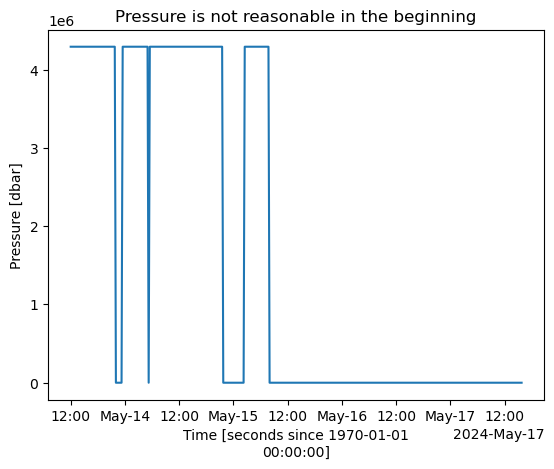

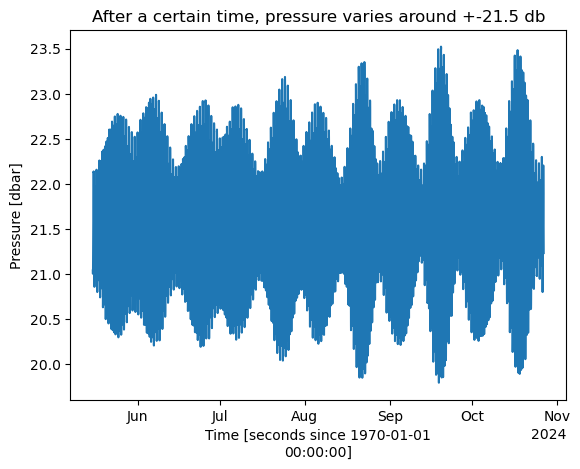

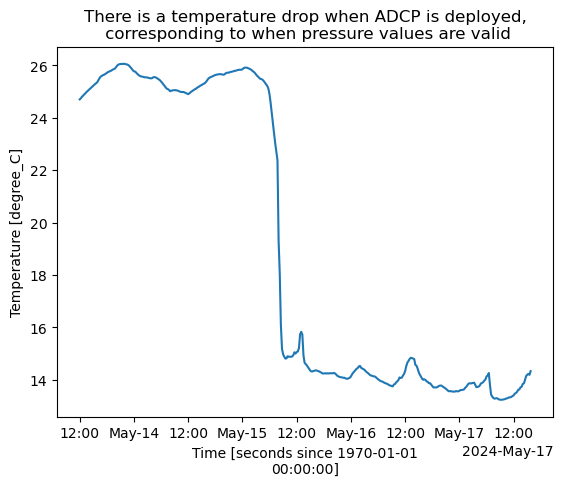

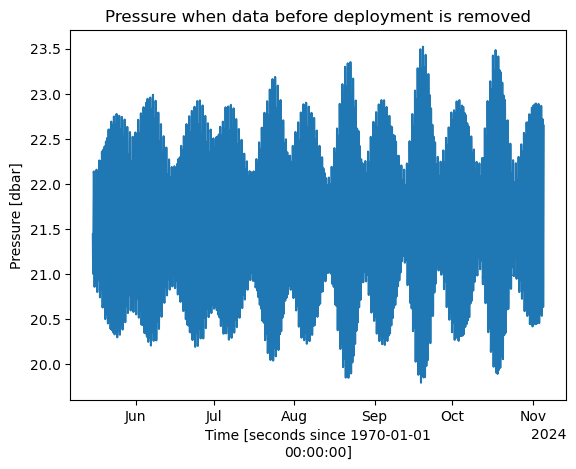

In [22]:

ds.pressure.isel(time=slice(0, 400)).plot()
plt.title('Pressure is not reasonable in the beginning')
plt.show()

ds.pressure.isel(time=slice(200,16000)).plot()
plt.title('After a certain time, pressure varies around +-21.5 db')
plt.show()

ds.temp.isel(time=slice(0, 400)).plot()
plt.title('There is a temperature drop when ADCP is deployed,\n corresponding to when pressure values are valid')
plt.show()

deployment_time = np.datetime64("2024-05-15T12:00:00") #read off from temperature plot

ds_1 = ds.sel(time=slice(deployment_time, None))

ds_1.pressure.plot()
plt.title('Pressure when data before deployment is removed')
plt.show()


### Controling of bin heights relative to transducer and seafloor

Range values without tranducers height: [ 2.12  3.12  4.12  5.12  6.12  7.12  8.12  9.12 10.12 11.12 12.12 13.12
 14.12 15.12 16.12 17.12 18.12 19.12 20.12 21.12 22.12 23.12 24.12 25.12]
Range values with tranducers height added: [ 3.52       4.52       5.52       6.52       7.52       8.5199995
  9.5199995 10.5199995 11.5199995 12.5199995 13.5199995 14.5199995
 15.5199995 16.52      17.52      18.52      19.52      20.52
 21.52      22.52      23.52      24.52      25.52      26.52     ]


c:\Users\karoa\miniconda3\envs\mhkit\Lib\site-packages\mhkit\dolfyn\adp\clean.py:90: UserWarning: The 'range_offset' is either already known or can be calculated from 'bin1_dist_m': 0.23999999463558197 m. If you would like to override this value with 1.4 m, ignore this warning. If you do not want to override this value, you do not need to use this function.
  warnings.warn(


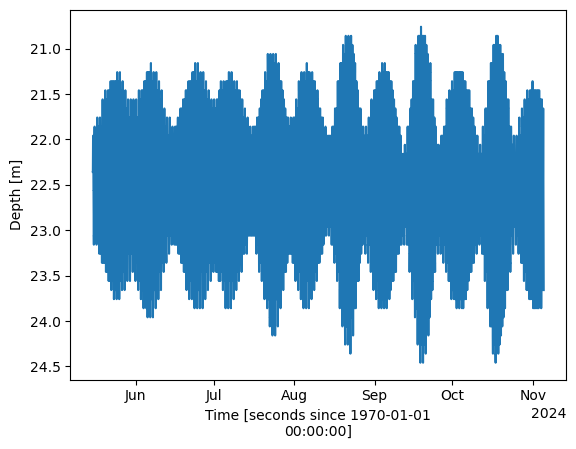

In [23]:
# 0 of range corresponds to transducers height, not seafloor

# original range start at 2.12
# but setup is first cell range 2.10
print(f"Range values without tranducers height: {ds_1['range'].values}")

# add 1.5m tranducer height to range and depth
da_1 = api.clean.set_range_offset(ds_1, 1.40)

print(f"Range values with tranducers height added: {ds_1['range'].values}")

# Surface variation accounted for, depth varies
ds_1.depth.plot()
plt.gca().invert_yaxis()
plt.show()



### Controlling that values of pitch, roll and heading are ~constant

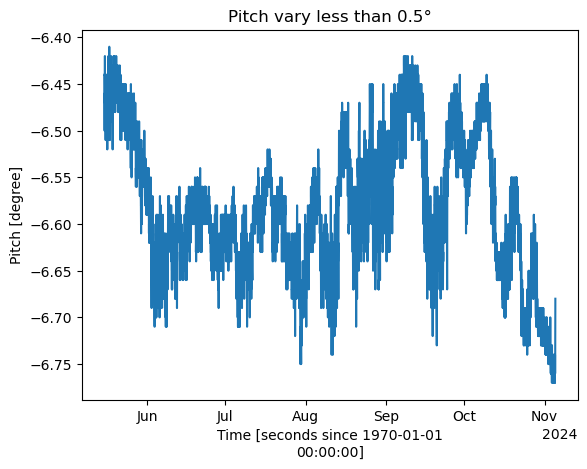

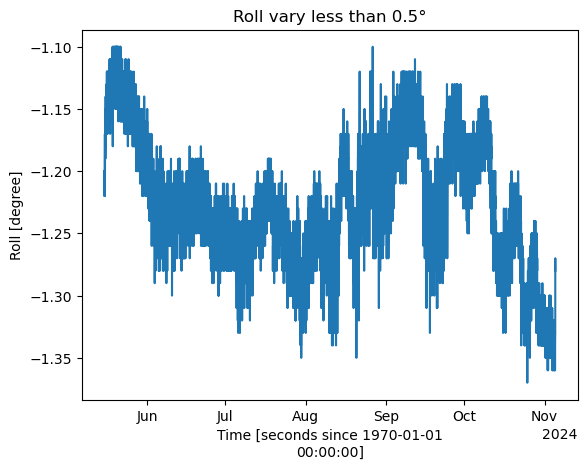

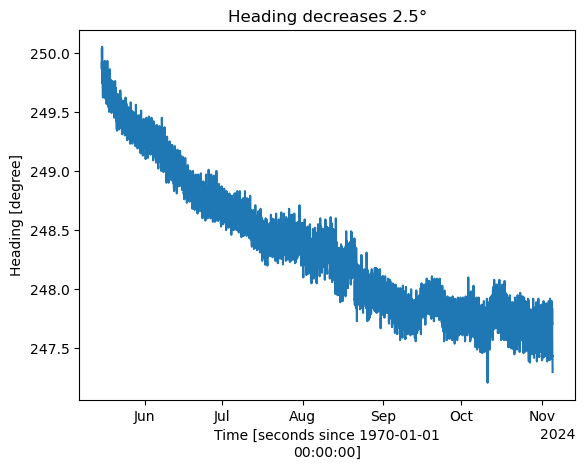

In [24]:
ds_1.pitch.plot()
plt.title('Pitch vary less than 0.5°')
plt.show()
ds_1['roll'].plot()
plt.title('Roll vary less than 0.5°')
plt.show()
ds_1.heading.plot()
plt.title('Heading decreases 2.5°')
plt.show()


### Removing surface interference and filtering tides

In order to filter tides from the velocity, the range coordinate (which vary in time) is normalized and interpolated to a constant interval. The interval is choosen so that surface interference is removed. 

Thereafter, a lowpass filter is applied on velocity and temperature. Data is then reconverted to the original coordinate. 

#### Normalizing range and interpolating to constant interval

In [25]:
ds_interp = ds_1.copy()

# Create normalized height coordinate (z/h)
ds_interp = ds_interp.assign_coords(zn = ds_interp['range'] / ds_interp['depth'])

# New normalized height grid to interpolate to
# start at 0.15 corresponds to 3.4 ~ first measurement
# end at 0.85 corresponds to removing upper 15% below surface
# 0.05% spacing corresponds to 1.1 m ~ cell size=1m
zn_new = np.arange(0.15,0.85+0.05,0.05)  

# Apply interpolation to each profile
vel_interp = xr.apply_ufunc(
    my.interp_profile,
    ds_interp['vel'],       # (dir, range, time)
    ds_interp['zn'],        # (range, time)
    kwargs={'coord_new': zn_new},
    input_core_dims=[['range'], ['range']],  
    output_core_dims=[['zn_new']],
    exclude_dims=set(('range',)),
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
    dask_gufunc_kwargs={'output_sizes': {'zn_new': len(zn_new)}},
)

# Assign the new coordinate
vel_interp = vel_interp.assign_coords(zn_new=zn_new).transpose('dir', 'zn_new', 'time')
ds_interp['vel_interp'] = vel_interp

#### Filtering

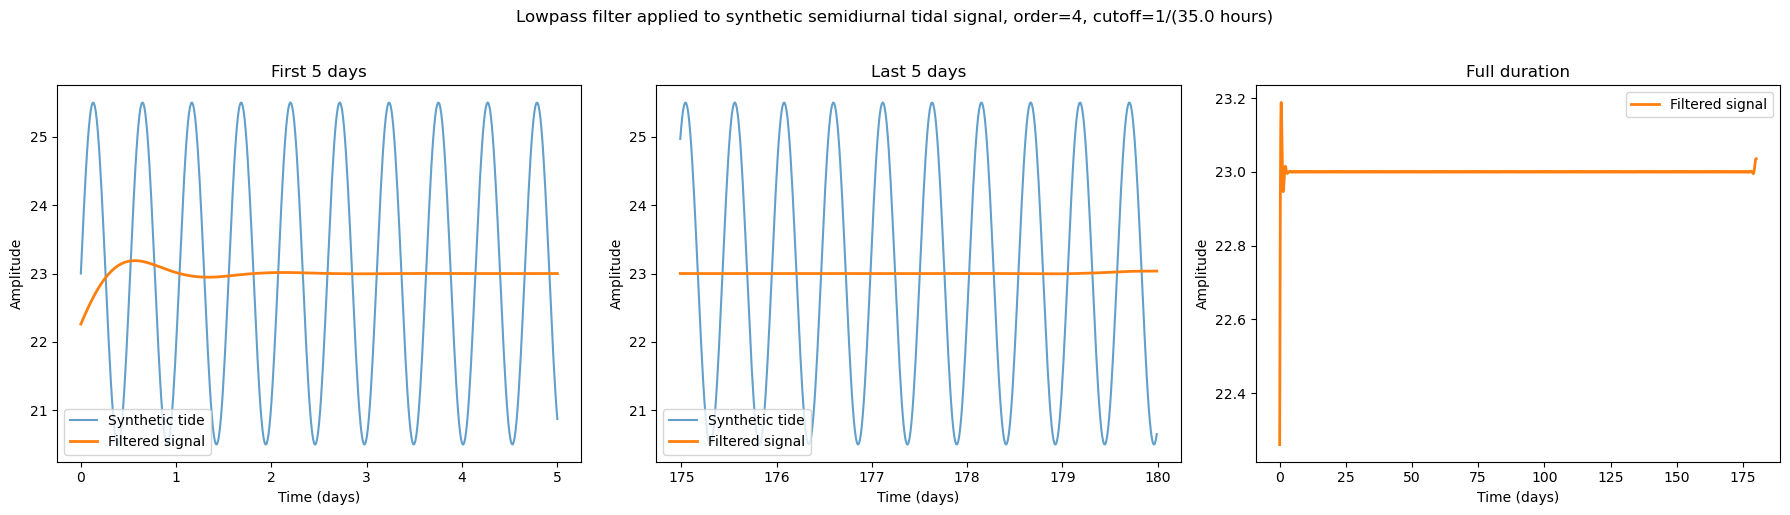

In [26]:
# Filter parameters 
# Cutoff and order are given from filtering synthetic tidal signal.
order = 4                   # choice of how sharply to filter
fs= 1/(15 * 60)             # Sampling rate, data is averaged, time step 15 min
cutoff_period = 35 * 3600   # Tidal frequency cutoff corresponding to period of x hours
cutoff = 1 / cutoff_period  
nyq = 0.5 * fs              # highest detectable frequency
normal_cutoff = cutoff/nyq

# Design filter
sos = butter(order, normal_cutoff, btype='lowpass', output='sos') 

# Synthetic tidal signal
duration = 6 * 30 * 24 * 3600  # 6 months
dt = 15 * 60                   # 15 intervals
t = np.arange(0, duration, dt)

T = 12.42 * 3600        # Semidiurnal tide has period of ~12.42 hours
omega = 2 * np.pi / T   # Angular frequency

tidal_signal = 23 + 2.5 * np.sin(omega * t)

# Apply filter on tidal signal
filtered_signal = sosfiltfilt(sos, tidal_signal)

# Plot tidal signal before and after fitlering
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
t_days = t / (24 * 3600)

# First 5 days
mask_first = t_days <= 5
ax1.plot(t_days[mask_first], tidal_signal[mask_first], label='Synthetic tide', alpha=0.7)
ax1.plot(t_days[mask_first], filtered_signal[mask_first], label='Filtered signal', linewidth=2)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Amplitude')
ax1.set_title('First 5 days')
ax1.legend()

# Last 5 days
mask_last = t_days >= (t_days[-1] - 5)
ax2.plot(t_days[mask_last], tidal_signal[mask_last], label='Synthetic tide', alpha=0.7)
ax2.plot(t_days[mask_last], filtered_signal[mask_last], label='Filtered signal', linewidth=2)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Amplitude')
ax2.set_title('Last 5 days')
ax2.legend()

# Full duration of filtered signal only
ax3.plot(t_days, filtered_signal, label='Filtered signal', linewidth=2, color='tab:orange')
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('Amplitude')
ax3.set_title('Full duration')
ax3.legend()

plt.suptitle(f'Lowpass filter applied to synthetic semidiurnal tidal signal, order={order}, cutoff=1/({(cutoff_period/3600)} hours)', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# Apply the filter on velocity and temperature
vel_no_tides = sosfiltfilt(sos, ds_interp['vel_interp'])
temp_no_tides = sosfiltfilt(sos, ds_interp['temp'])

# Assign dimensions and coordinates
vel_no_tides = xr.DataArray(
    vel_no_tides,
    dims=('dir', 'zn_new', 'time'),
    coords={
        'dir': ds_interp['dir'],
        'range': ds_interp['zn_new'],
        'time': ds_interp['time']
    },
    name='vel_no_tides'
)

temp_no_tides = xr.DataArray(
    temp_no_tides,
    dims=('time'),
    coords={'time': ds_interp['time']},
    name='temp_no_tides'
)

ds_filt = ds_interp.copy()
ds_filt['vel_no_tides'] = vel_no_tides
ds_filt['temp_no_tides'] = temp_no_tides

#### Reconverting to range and interpolating back

In [28]:
#Reconvert the normalized height in real height (zn_new*h)
ds_filt = ds_filt.assign_coords(
z = ds_filt['zn_new'] * ds_filt['depth'] 
)

# Interpolating back to range coordinate
vel_filt = xr.apply_ufunc(
    my.interp_profile,
    ds_filt['vel_no_tides'],       # (dir, zn_new, time)
    ds_filt['z'],                  # (zn_new)
    kwargs={'coord_new': ds_filt['range'].values},  #target grid: fixed grid
    input_core_dims=[['zn_new'],['zn_new']], 
    output_core_dims=[['range']],
    exclude_dims=set(('zn_new',)),
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
    dask_gufunc_kwargs={'output_sizes': {'range': len(ds_filt['range'])}},
)

# Assign the new coordinate
vel_filt = vel_filt.assign_coords(range=ds_filt['range']).transpose('dir', 'range', 'time')

# Save results to new dataset
ds_2 = ds_1.copy()
ds_2['vel_filt'] = vel_filt
ds_2['vel_filt'].attrs = {
    'long_name': 'Velocity filtered',
    'units': 'Water Velocity m s-1',
    'description': 'Velocity filtered from tidal flucuations'
}

ds_2['temp_filt'] = ds_filt['temp_no_tides']
ds_2['temp_filt'].attrs = {
    'long_name': 'Temperature filtered',
    'units': 'Degree C',
    'description': 'Temperature filtered from tidal flucuations'
}

#### NaN values does not need to be put back after filtering. 

In [29]:
ds_test = ds_2.copy()

mask = np.isfinite(ds_1['vel'])

#when value in ds_1['vel'] is finite, keep vel_filt value, otherwise replace with NaN value from ds_1['vel']
ds_test['vel_filt'] = ds_test['vel_filt'].where(mask, other=ds_1['vel'])

print('ds_1 (before filtering) does not seems to contain any NaNs that are already not in ds_2 (after filtering)')
print('NaN values in ds_1.vel:', np.isnan(ds_1['vel'].values).sum())
print('NaN values in ds_2.vel_filt:', np.isnan(ds_2['vel_filt']).values.sum())
print('NaN values in ds_2.vel_filt after inserting NaNs from ds_1.vel:', np.isnan(ds_test['vel_filt'].values).sum())

ds_1 (before filtering) does not seems to contain any NaNs that are already not in ds_2 (after filtering)
NaN values in ds_1.vel: 16672
NaN values in ds_2.vel_filt: 623556
NaN values in ds_2.vel_filt after inserting NaNs from ds_1.vel: 623556


#### Results from removing surface interference and filtering

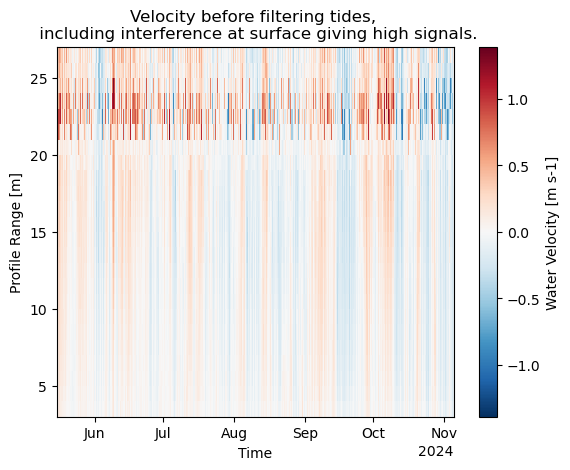

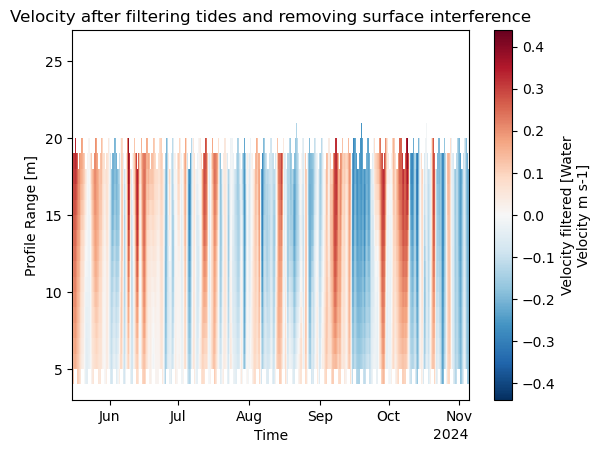

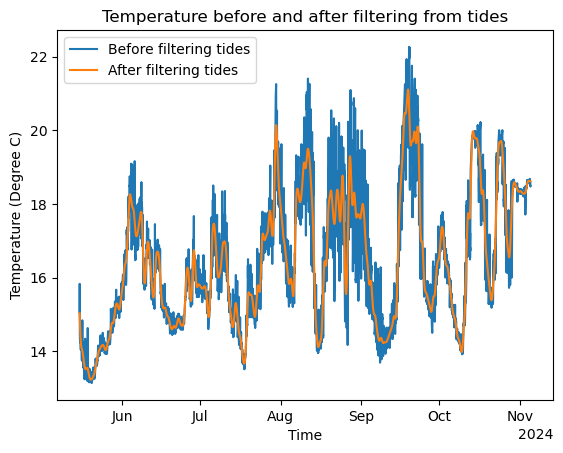

In [30]:
ds_2['vel'][0].plot()
plt.xlabel('Time')
plt.title('Velocity before filtering tides, \n including interference at surface giving high signals.')
plt.show()

ds_2['vel_filt'][0].plot()
plt.xlabel('Time')
plt.title('Velocity after filtering tides and removing surface interference')
plt.show()

ds_2['temp'].plot(label='Before filtering tides')
ds_2['temp_filt'].plot(label='After filtering tides')
plt.xlabel('Time')
plt.ylabel('Temperature (Degree C)')
plt.legend()
plt.title('Temperature before and after filtering from tides')
plt.show()

### Applying correlation filter

Correlation tells how reliable the signal in a bin is based on comparing it to the expected pattern. 


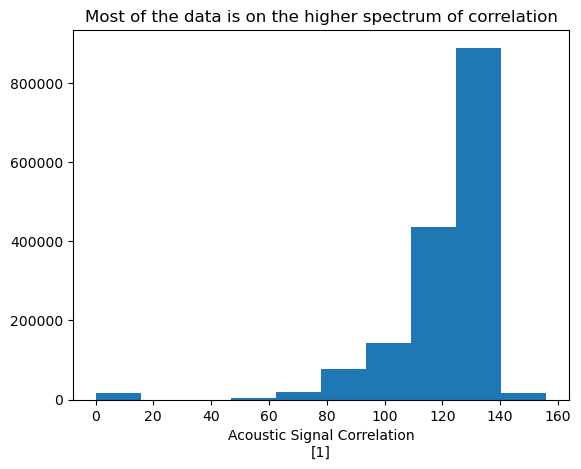

Data removed for vel_filt: 51 (0.01%)


In [31]:
ds_2.corr.plot()
plt.title('Most of the data is on the higher spectrum of correlation')
plt.show()

corr_thresh=100
ds_3 = my.correlation_filter(ds_2, thresh=corr_thresh) 

my.print_data_removed(ds_2, ds_3, 'vel_filt')

### Removing outliers from signal amplitude

The signal amplitude is strong in the beginning and then decreases. Along the beam, there should only be values lower than those in the beginning, otherwise there is interference from e.g. fish, diver etc.


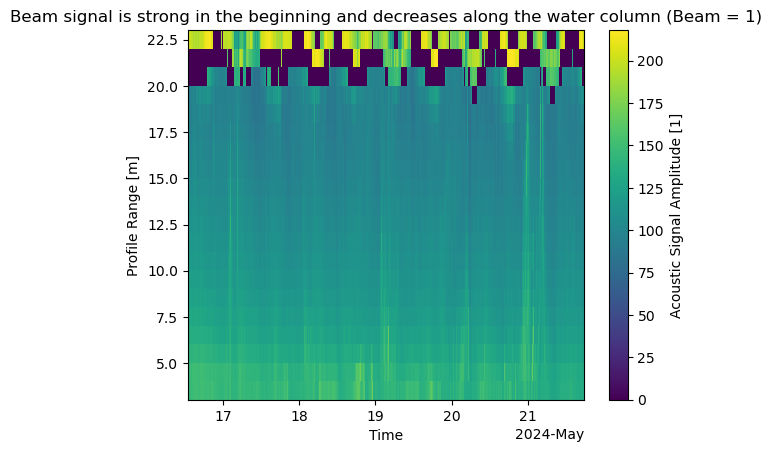

Max signals for each beam at the start [193, 190, 190, 203] 
Median signals for each beam at the end [90.0, 91.0, 87.0, 93.0] 
Data removed for vel_filt: 696 (0.07%)


In [32]:
ds_3.amp[0].isel(range=slice(0,20),time=slice(100,600)).plot()
plt.xlabel('Time')
plt.title('Beam signal is strong in the beginning and decreases along the water column (Beam = 1)')
plt.show()

#finding max values of the signal in the beginning to decide bottom threshold
max_signals =[]
for i in(0,1,2,3):
     max_signals.append(ds_3.amp[i].sel(range=slice(2.12,4.12)).max().item())
print(f'Max signals for each beam at the start {max_signals} ')

#finding median values of the signal in the end to decide surface threshold
median_signals =[]
for i in(0,1,2,3):
     median_signals.append(ds_3.amp[i].sel(range=slice(18,20)).median().item())
print(f'Median signals for each beam at the end {median_signals} ')

#outliers are set to NaN assuming linear decay of signal, 
#and if less than 3 beams valid, velocity is set to Nan too.
ds_4 = my.remove_outliers(ds_3, bottom_threshold=225, surface_threshold=100) 
my.print_data_removed(ds_3, ds_4, 'vel_filt')

###  Controlling coordinate system and setting declination

In [33]:
#earth coordinate system is already used
print(f"Coordinate system: {ds.attrs['coord_sys']}")

#need to set declination
print(f"Declination: {ds.attrs.get('declination', 'Not set')}")

dolfyn.set_declination(ds_4, -0.90) #I assumed lat=37N, long=8W, May 2024 which gave declination=0.9W. Quite low, could be neglied in this case
print(f"Declination: {ds_4.attrs.get('declination', 'Not set')}")

Coordinate system: earth
Declination: Not set
Declination: -0.9


### Adding quality flags to datasets
Following the Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme.
Flagging arrays are created for corresponding dataset, then saved as ancillary variables.

#### Starting with ds_r (data with only removal of data before deployment and adding transducer's height)

Flags will be added for
- Passing all tests
- Unkown
- Above surface
- Contaminated from surface interference
- Below correlation threshold x
- Signal amplitude outlier
- Missing data


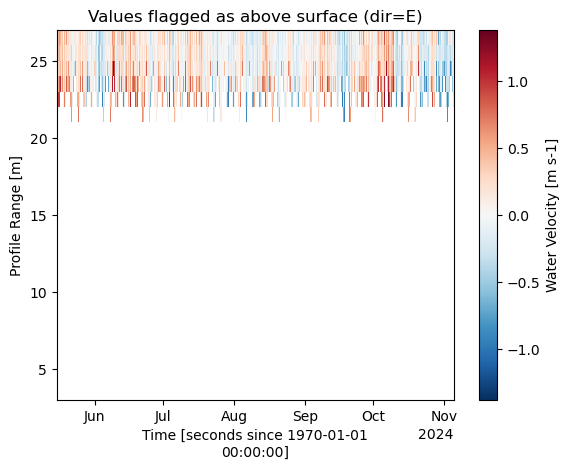

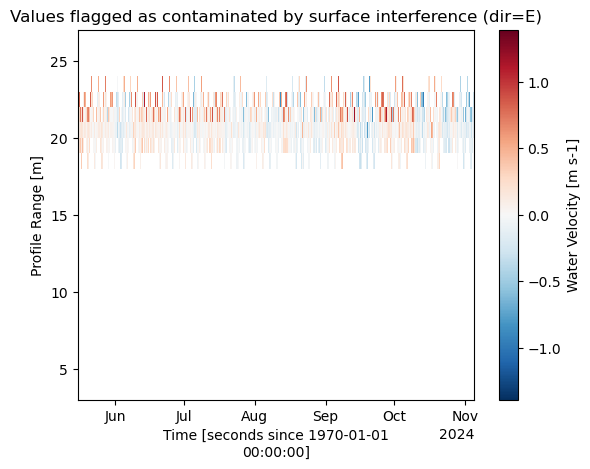

In [34]:
ds_r = ds_1.copy()

# Creating flagging arrays for raw data, default values are (2,2) indicating unknown quality
qc1_r = xr.full_like(ds_r['vel'], 2)        # primary quality flags
qc2_r = xr.full_like(ds_r['vel'], 2)        # secondary quality flags

# Create masks 
# values above surface, True where range > depth
mask_above_surface = ds_r['range'] > ds_r['depth']   
# values contaminated from surface interference (upper 15%)
mask_surface_interference = (ds_r['range']/ds_r['depth'] >= 0.85) & (ds_r['range']/ds_r['depth'] <= 1)

# Apply masks to corresponding values to flagging arrays
qc1_r, qc2_r = my.apply_qc_mask(mask_above_surface, (4, 3), qc1_r, qc2_r)
qc1_r, qc2_r = my.apply_qc_mask(mask_surface_interference, (4, 4), qc1_r, qc2_r)

# Plot masked values
my.plot_masked(mask_above_surface, ds_r['vel'], 'above surface')
my.plot_masked(mask_surface_interference, ds_r['vel'], 'contaminated by surface interference')



<!-- ###  Saving data -->

In [35]:
qc1_r = qc1_r.transpose('dir', 'range', 'time')
qc2_r = qc2_r.transpose('dir', 'range', 'time')



# Add the numeric QC flags
ds_r['vel_qc_primary'] = qc1_r.assign_attrs({
    'long_name': 'Quality flags for variable (primary level)',
    'flag_values': [1, 2, 3, 4, 9],    
    'flag_meanings': 
        '1=Good \n'
        '2=Unknown \n'
        '3=Questionable \n'
        '4=Bad \n'
        '9=Missing_data',
    'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
})


# Add the descriptive QC flags
ds_r['vel_qc_secondary'] = qc2_r.assign_attrs({
        'long_name': 'Quality flag descriptions for variable (secondary level)',
        'flag_values': [1, 2, 3, 4, 5, 6, 7],  
        'flag_meanings':
            '1=Passed all tests \n'
            "2=Unkown \n"
            '3=Above_surface\n'
            '4=Contaminated_from_surface_interference\n'
            '5=Below_correlation_threshold_x\n'
            '6=Signal_amplitude_outliers\n'
            '7=Missing_data\n',
        'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
    })

# Link as ancillary variables
ds_r['vel'].attrs['ancillary_variables'] = 'vel_qc_primary vel_qc_secondary'

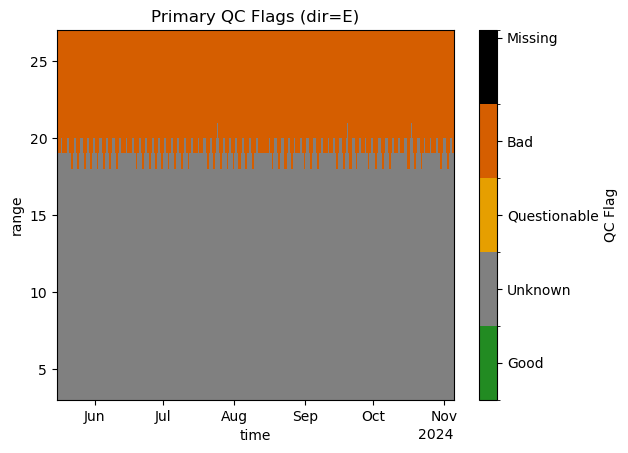

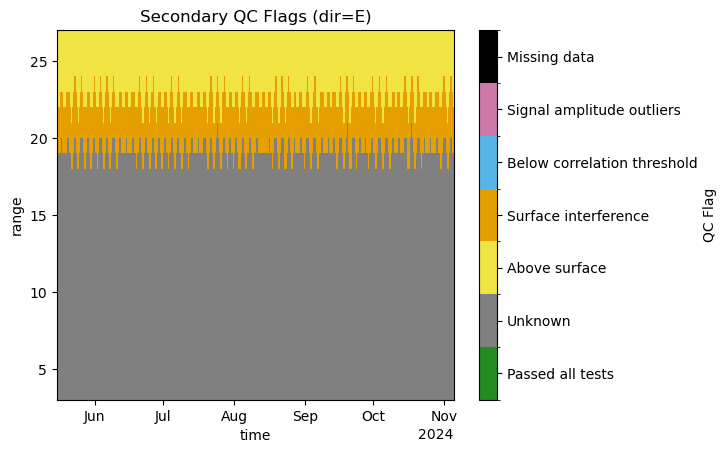

In [36]:
my.plot_qc_primary(ds_r, direction=0)

my.plot_qc_secondary(ds_r, direction=0, num_flags=7)  

#### For processed dataset

Flags will be added for
- Passing all tests
- Unkown
- Above surface
- Contaminated from surface interference
- Below correlation threshold x
- Signal amplitude outlier
- Interpolated values
- Missing data

### Saving data

In [37]:
dolfyn.save(ds_r, 'A0524000_raw.nc')        # raw dataset including quality flags
dolfyn.save(ds_4, 'A0524000_processed.nc')  # processed dataset